<a href="https://colab.research.google.com/github/Tuna10001/Assignments-on-remote-sensing-and-water-quality-data-analysis/blob/main/Isotope_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
# Load the Excel file
file_path = "/content/Isotopes_data_analysis.xlsx"  # Update if needed
df = pd.read_excel(file_path)  # Adjust sheet name if needed

# Display the first few rows
df.head()



,Code_1,Type_3,Feature,"δ18O, in ‰","δ2H, in ‰",D-excess
0,WP07,RF,Waterpan,2.59,19.8,-0.92
1,WP08,RF,Waterpan,1.22,8.2,-1.56
2,WP11,GF,Waterpan,-1.83,-7.9,6.74
3,WP12,RF,Waterpan,1.72,14.4,0.64
4,WP09,RF,Waterpan,2.27,14.9,-3.26


In [ ]:
print(df.columns)


Index(['Code_1', 'Type_3', 'Feature', 'δ18O, in ‰', 'δ2H, in ‰', 'D-excess'], dtype='object')


In [ ]:
df.columns = df.columns.str.strip()  # Removes any leading/trailing spaces


In [ ]:
print(df.columns)  # Print column names to check for spaces
df.columns = df.columns.str.strip()  # Remove extra spaces


Index(['Code_1', 'Type_3', 'Feature', 'δ18O, in ‰', 'δ2H, in ‰', 'D-excess'], dtype='object')


In [ ]:
# Clean column names by stripping leading and trailing whitespaces
df.columns = df.columns.str.strip()

# Check the cleaned column names
print(df.columns)


Index(['Code_1', 'Type_3', 'Feature', 'δ18O, in ‰', 'δ2H, in ‰', 'D-excess'], dtype='object')


In [ ]:
print(df.columns)


Index(['Code_1', 'Type_3', 'Feature', 'δ18O, in ‰', 'δ2H, in ‰', 'D-excess'], dtype='object')


In [ ]:
# Drop the duplicate 'Feature' column
df = df.loc[:, ~df.columns.duplicated()]

# Clean column names by stripping leading and trailing whitespaces again
df.columns = df.columns.str.strip()

# Verify the column names again to ensure everything is correct
print(df.columns)

# Now you should be able to access the columns without issues


Index(['Code_1', 'Type_3', 'Feature', 'δ18O, in ‰', 'δ2H, in ‰', 'D-excess'], dtype='object')


In [ ]:
import pandas as pd

# Load the file
file_path = "/content/Isotopes_data_analysis.xlsx"  # Update path if needed
df = pd.read_excel(file_path)

# Check column names
print("Available Columns:", df.columns)


Available Columns: Index(['Code_1', 'Type_3', 'Feature', 'δ18O, in ‰', 'δ2H, in ‰', 'D-excess'], dtype='object')


In [ ]:
# Check column names
print("Available Columns:", df.columns)

Available Columns: Index(['Code_1', 'Type_3', 'Feature', 'δ18O, in ‰', 'δ2H, in ‰', 'D-excess'], dtype='object')


In [ ]:
print(df.columns)  # Check actual column names


Index(['Code_1', 'Type_3', 'Feature', 'δ18O, in ‰', 'δ2H, in ‰', 'D-excess'], dtype='object')


In [ ]:
pip install adjustText

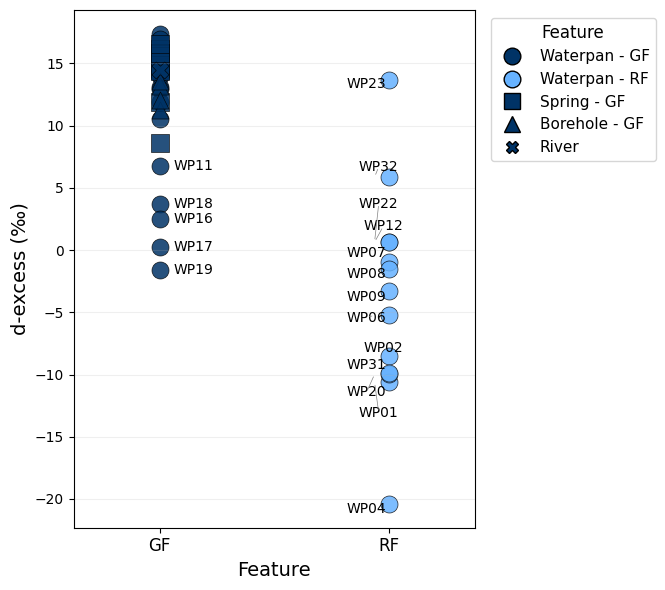

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from adjustText import adjust_text

# — PREPARE DATA —
df.columns = df.columns.str.strip()

def classify_feature(code):
    code = str(code)
    if code.startswith("WP"):   return "Waterpan"
    if code.startswith("SP"):   return "Spring"
    if code.startswith("BH"):   return "Borehole"
    if code.startswith("SW"):   return "River"
    return "Other"

df["Feature"] = df["Code_1"].apply(classify_feature)
df = df[df["Feature"] != "Other"].copy()
df["D-excess"] = pd.to_numeric(df["D-excess"], errors="coerce")
df.dropna(subset=["D-excess"], inplace=True)

# — STYLING PARAMETERS —
colors = {"GF": "#003366", "RF": "#66B2FF"}
markers = {"Waterpan": "o", "Spring": "s", "Borehole": "^", "River": "X"}
label_order = [
    "Waterpan - GF", "Waterpan - RF",
    "Spring - GF", "Spring - RF",
    "Borehole - GF", "Borehole - RF",
    "River"
]
x_map = {"GF": 0, "RF": 0.8}
rf_texts = []
gf_texts = []

# — PLOT —
plt.figure(figsize=(8, 6))
ax = plt.gca()

for t3, col in colors.items():
    for feat, m in markers.items():
        sub = df[(df["Type_3"] == t3) & (df["Feature"] == feat)]
        if sub.empty: continue

        xs = np.full(len(sub), x_map[t3])
        ax.scatter(xs, sub["D-excess"], c=col, marker=m, s=150,
                   edgecolor="k", linewidth=0.5, alpha=0.85)

        for _, row in sub.iterrows():
            x, y, code = x_map[t3], row["D-excess"], row["Code_1"]

            # Label RF waterpans (all)
            if t3 == "RF" and feat == "Waterpan":
                txt = ax.text(x - 0.05, y, code,
                              fontsize=10, va="center", ha="right")
                rf_texts.append(txt)

            # Label only selected GF waterpans
            elif t3 == "GF" and feat == "Waterpan" and code in {"WP11", "WP16", "WP17", "WP18", "WP19", "WP23"}:
                txt = ax.text(x + 0.05, y, code,
                              fontsize=10, va="center", ha="left")
                gf_texts.append(txt)

# — Adjust RF waterpan labels only —
adjust_text(rf_texts,
            only_move={'text': 'y'},
            force_text=(0.5, 0.5),
            expand_points=(1.2, 1.2),
            arrowprops=dict(arrowstyle='-', lw=0.5, color='gray'),
            autoalign='y')

# — AXES & GRID —
ax.set_xticks(list(x_map.values()))
ax.set_xticklabels(list(x_map.keys()), fontsize=12)
ax.set_xlim(-0.3, 1.1)
ax.set_xlabel("Feature", fontsize=14)
ax.set_ylabel("d-excess (‰)", fontsize=14)
ax.grid(axis='y', alpha=0.2)

# — LEGEND —
handles, labels = [], []
for lbl in label_order:
    if " - " in lbl:
        feat, t3 = lbl.split(" - ")
        if not df[(df["Feature"] == feat) & (df["Type_3"] == t3)].empty:
            handles.append(
                Line2D([], [], marker=markers[feat], color="w",
                       markerfacecolor=colors[t3], markeredgecolor="k", markersize=12)
            )
            labels.append(lbl)
    elif lbl == "River":
        river_df = df[df["Feature"] == "River"]
        if not river_df.empty:
            rt3 = river_df["Type_3"].iloc[0] if "Type_3" in river_df.columns else "RF"
            handles.append(
                Line2D([], [], marker=markers["River"], color="w",
                       markerfacecolor=colors.get(rt3, "gray"),
                       markeredgecolor="k", markersize=8)
            )
            labels.append("River")

ax.legend(handles, labels, title="Feature",
          bbox_to_anchor=(1.02, 1), loc="upper left",
          fontsize=11, title_fontsize=12)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()



In [ ]:
print(df["Feature"].unique())


['Waterpan' 'Spring' 'Borehole' 'River']


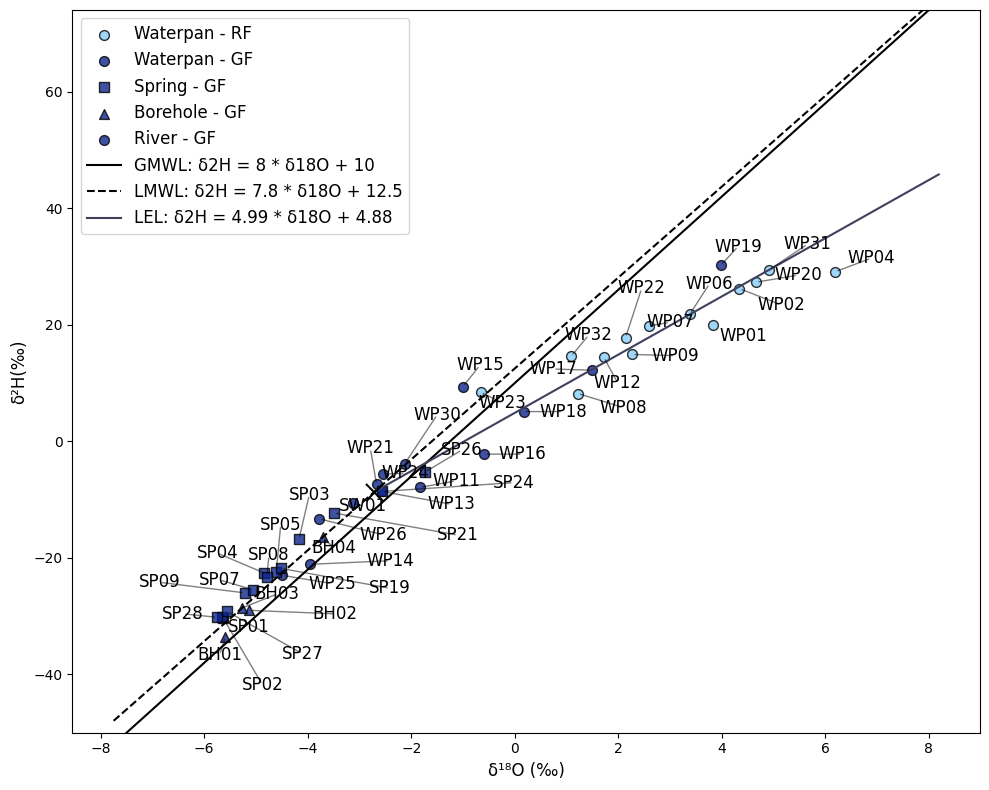

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text

# Define colors for groups RF and GF
sample_colors = {"RF": "lightskyblue", "GF": "#0D258C"}

# Define marker styles for each feature
marker_styles = {
    "Waterpan": "o",  # Circle # Corrected from "Water Pan"
    "Spring": "s",  # Square
    "Borehole": "^"  # Triangle
}

# Define LMWL and GMWL parameters
lmwl_slope = 7.8
lmwl_intercept = 12.5
gmwl_slope = 8.0
gmwl_intercept = 10  # fixed missing gmwl_intercept

# Extract Water Pan samples for LEL calculation
df_wp = df[df["Feature"] == "Waterpan"].copy() # Corrected from "Water Pan"
X_wp = df_wp["δ18O, in ‰"].values.reshape(-1, 1)
y_wp = df_wp["δ2H, in ‰"].values.reshape(-1, 1)

# Fit a regression line to Water Pan samples (LEL approximation)
reg = LinearRegression().fit(X_wp, y_wp)
lel_slope = reg.coef_[0][0]
lel_intercept = reg.intercept_[0]

# Find intersection δ18O where LMWL = LEL
delta_18O_intersect = (lel_intercept - lmwl_intercept) / (lmwl_slope - lel_slope)
delta_2H_intersect = lmwl_slope * delta_18O_intersect + lmwl_intercept

# Ensure the intersection is within dataset range
delta_18O_intersect = np.clip(delta_18O_intersect, df["δ18O, in ‰"].min(), df["δ18O, in ‰"].max())

# Generate LEL from intersection point
x_lel = np.linspace(delta_18O_intersect, df["δ18O, in ‰"].max() + 2, 100)
y_lel = lel_slope * x_lel + lel_intercept

# Generate LMWL and GMWL across plot
x_range = np.linspace(df["δ18O, in ‰"].min() - 2, df["δ18O, in ‰"].max() + 2, 100)
y_gmwl = gmwl_slope * x_range + gmwl_intercept
y_lmwl = lmwl_slope * x_range + lmwl_intercept

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Store text annotations for adjust_text
texts = []

# Plot sample points with correct colors and black edges
for feature in df["Feature"].unique():
    if "Type_3" in df.columns:
        for sample_type, color in sample_colors.items():
            subset = df[(df["Feature"] == feature) & (df["Type_3"] == sample_type)]
            if not subset.empty:
                marker = marker_styles.get(feature, "o")  # Default to circle
                scatter = ax.scatter(
                    subset["δ18O, in ‰"], subset["δ2H, in ‰"],
                    color=color, edgecolors="black", label=f"{feature} - {sample_type}",
                    alpha=0.8, s=50, marker=marker
                )
                # Add labels to points
                for i, row in subset.iterrows():
                    text = ax.text(row["δ18O, in ‰"], row["δ2H, in ‰"], row["Code_1"], fontsize=12)
                    texts.append(text)
    else:
        print("Column 'Type_3' not found. Check DataFrame column names.")

# Plot GMWL as a solid black line
ax.plot(x_range, y_gmwl, color='black', linestyle='-', linewidth=1.5, label="GMWL: δ2H = 8 * δ18O + 10")

# Plot LMWL as a dashed black line
ax.plot(x_range, y_lmwl, color='black', linestyle='--', linewidth=1.5, label="LMWL: δ2H = 7.8 * δ18O + 12.5")

# Plot LEL with **light gray**
ax.plot(x_lel, y_lel, color='#3F405C', linestyle='-', linewidth=1.5, label=f"LEL: δ2H = {lel_slope:.2f} * δ18O + {lel_intercept:.2f}")

# Mark LEL intersection with black cross
ax.scatter(delta_18O_intersect, delta_2H_intersect, color='Black', marker='x', s=150, zorder=3)

# Labels and legend
ax.set_xlabel("δ¹⁸O (‰)", fontsize=12)
ax.set_ylabel("δ²H(‰)",fontsize=12)


ax.set_ylim(-50, 74)
ax.set_xlim()


 #Remove gridlines for a cleaner look
ax.grid(False)

ax.legend(fontsize=12, title_fontsize=12)


# Adjust text labels to prevent overlap (remove arrows and add text padding)
adjust_text(texts, force_points=(6, 6), arrowprops=dict(arrowstyle='-', color='black', alpha=0.5), autoalign='xy', only_move={'points':'xy', 'text':'xy'}, expand_points=(2, 2), expand_text=(1.2, 1.2))

plt.tight_layout()
plt.show()

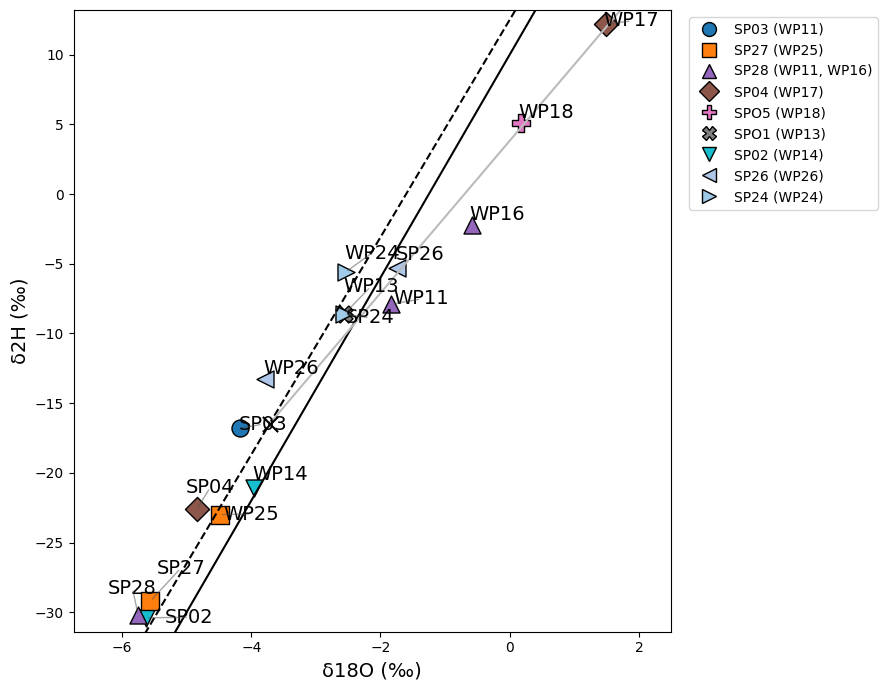

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text
from matplotlib.lines import Line2D

# --- 1. clean names
df.columns = df.columns.str.strip()

# --- 2. compute original LEL on ALL water-pans
df_full = df.copy()
df_full["Feature"] = df_full["Feature"].replace({
    "Waterpan": "Water Pan",
    "Spring":   "Spring",
    "Borehole": "Borehole"
})
wp_full = df_full[df_full["Feature"] == "Water Pan"]
Xf = wp_full["δ18O, in ‰"].values.reshape(-1,1)
yf = wp_full["δ2H, in ‰"].values.reshape(-1,1)
reg = LinearRegression().fit(Xf, yf)
lel_slope, lel_int = reg.coef_[0][0], reg.intercept_[0]

# --- 3. define MWLs
lmwl_m, lmwl_b = 7.8, 12.5
gmwl_m, gmwl_b = 8.0, 10

# --- 4. filter to just the 8 springs + their pans
relevant = {
    "SP03": ["WP11"],
    "SP27": ["WP25"],
    "SP28": ["WP11","WP16"],
    "SP04": ["WP17"],
    "SPO5": ["WP18"],
    "SPO1": ["WP13"],
    "SP02": ["WP14"],
    "SP26": ["WP26"],
    "SP24": ["WP24"]
}
codes = list(relevant.keys()) + sum(relevant.values(), [])
df = df_full[df_full["Code_1"].isin(codes)].copy()

# normalize feature names
df["Feature"] = df["Feature"].replace({
    "Waterpan": "Water Pan",
    "Spring":   "Spring",
    "Borehole": "Borehole"
})

# --- 5. assign each spring-group its own CB-safe color & marker
# avoid red(#d62728), green(#2ca02c), yellow(#bcbd22)
palette = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#17becf",  # cyan
    "#aec7e8", # light blue
    "#a0cbe8", # light steel blue
    "#ffbb78", # light orange
]

markers = ["o","s","^","D","P","X","v","<",">","h"]
group_style = {}
legend_handles = {} # Dictionary to store handles for legend

for i, (spring, pans) in enumerate(relevant.items()):
    col, mk = palette[i % len(palette)], markers[i % len(markers)]
    group_style[spring] = {"color": col, "marker": mk}
    legend_label = f"{spring} ({', '.join(pans)})"
    # Create a handle for the spring and its associated water pans
    handle = Line2D([], [], marker=mk, color="w",
                       markerfacecolor=col, markeredgecolor="k", markersize=10, label=legend_label)
    legend_handles[legend_label] = handle

    for wp in pans:
        group_style[wp] = {"color": col, "marker": mk}


# --- 6. intersection LEL & LMWL
xmin, xmax = df["δ18O, in ‰"].min(), df["δ18O, in ‰"].max()
xint = (lel_int - lmwl_b) / (lmwl_m - lel_slope)
xint = np.clip(xint, xmin, xmax)
yint = lmwl_m * xint + lmwl_b

# --- 7. build line arrays
x_all = np.linspace(xmin-1, xmax+1, 200)
y_gmwl = gmwl_m * x_all + gmwl_b
y_lmwl = lmwl_m * x_all + lmwl_b
x_lel  = np.linspace(xint, xmax+1, 200)
y_lel  = lel_slope * x_lel + lel_int

# --- 8. plot
fig, ax = plt.subplots(figsize=(9,7))
texts = []

for _,r in df.iterrows():
    code, feat = r["Code_1"], r["Feature"]
    x,y = r["δ18O, in ‰"], r["δ2H, in ‰"]
    style = group_style.get(code, {"color":"#bbbbbb","marker":"o"})
    ax.scatter(x, y,
               color=style["color"],
               marker=style["marker"],
               edgecolor="k",
               s=150,
               ) # Removed label here as we are creating custom handles


    texts.append(ax.text(x, y, code, fontsize=14))

# reference lines
ax.plot(x_all, y_gmwl, color="k", lw=1.5, label="GMWL")
ax.plot(x_all, y_lmwl, color="k", lw=1.5, ls="--", label="LMWL")
ax.plot(x_lel,  y_lel,  color="#bbbbbb", lw=1.5, label=f"LEL(orig): {lel_slope:.2f}·x+{lel_int:.1f}")
ax.scatter(xint, yint, color="k", marker="x", s=120, zorder=5,)

# Add the custom legend handles
ax.legend(handles=list(legend_handles.values()), bbox_to_anchor=(1.02,1), loc="upper left")


# axes & style
ax.set_xlabel("δ18O (‰)", fontsize=14)
ax.set_ylabel("δ2H (‰)", fontsize=14)
ax.set_xlim(xmin-1, xmax+1)
ax.set_ylim(df["δ2H, in ‰"].min()-1, df["δ2H, in ‰"].max()+1)
ax.grid(False)

adjust_text(texts,
            arrowprops=dict(arrowstyle="-", color="0.3", alpha=0.5),
            expand_points=(1.2,1.2))

plt.tight_layout()
plt.show()

In [ ]:
# prompt: where is spring S05 NOT PLOTTED

relevant = {
    "SP03": ["WP11","WP25"],
    "SP27": ["WP25"],
    "SP28": ["WP11","WP16"],
    "SP04": ["WP17"],
    "SPO5": ["WP18"],
    "SPO1": ["WP13"],
    "SP02": ["WP14"],
    "SP26": ["WP26"],
    "SP24": ["WP24"]
}


In [ ]:
# Given values
slope_LMWL = 4.99
intercept_LMWL = 4.88
slope_GMWL = 7.8
intercept_GMWL = 12.5

# Solve for δ18O at intersection
delta18O_intersect = (intercept_GMWL - intercept_LMWL) / (slope_LMWL - slope_GMWL)

# Solve for δ2H at the intersection using either equation (I'll use the LMWL equation)
delta2H_intersect = slope_LMWL * delta18O_intersect + intercept_LMWL

print("Intersection of GMWL and LMWL:")
print("δ18O =", delta18O_intersect)
print("δ2H =", delta2H_intersect)



Intersection of GMWL and LMWL:
δ18O = -2.7117437722419933
δ2H = -8.651601423487548


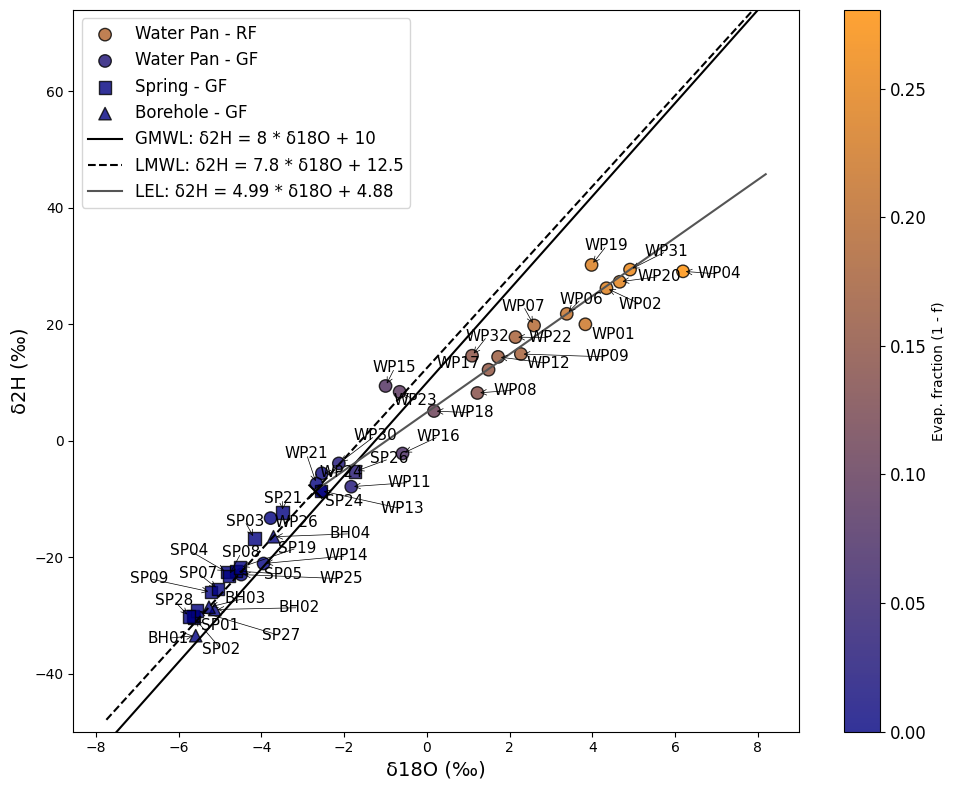

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text

# Effective fractionation factors for evaporation
alpha_eff_18O = 0.9847  # effective fractionation factor for δ18O under evaporation
alpha_eff_2H = 0.71      # effective fractionation factor for δ2H under evaporation

# Initial isotope values from precipitation (in ‰)
R0_18O = -2.7  # δ18O of precipitation
R0_2H  = -8.65 # δ2H of precipitation

# Function to calculate evaporation fraction (f) using Rayleigh fractionation for evaporation
def calculate_evaporation_fraction(sample, R0_18O, R0_2H, alpha_eff_18O, alpha_eff_2H):
    # Measured isotope values (in ‰)
    delta_18O = sample["δ18O, in ‰"]
    delta_2H  = sample["δ2H, in ‰"]

    # Convert to an absolute scale by adding 1000
    delta_18O_abs = delta_18O + 1000
    delta_2H_abs  = delta_2H + 1000
    R0_18O_abs    = R0_18O + 1000
    R0_2H_abs     = R0_2H + 1000

    # Effective enrichment factors (ε) (note: these are negative for evaporation)
    epsilon_18O = alpha_eff_18O - 1   # ~ -0.0153
    epsilon_2H  = alpha_eff_2H - 1    # ~ -0.09

    # Rayleigh formulation rearranged for fraction remaining:
    f_18O = (delta_18O_abs / R0_18O_abs) ** (1 / epsilon_18O)
    f_2H  = (delta_2H_abs  / R0_2H_abs)  ** (1 / epsilon_2H)

    # Average the estimates from δ18O and δ2H
    f = (f_18O + f_2H) / 2

    # Ensure f is within [0, 1]
    f = np.clip(f, 0, 1)

    return f

# Apply the function to the DataFrame
df['Evaporation Fraction'] = df.apply(
    calculate_evaporation_fraction, axis=1,
    R0_18O=R0_18O, R0_2H=R0_2H,
    alpha_eff_18O=alpha_eff_18O, alpha_eff_2H=alpha_eff_2H
)

# Calculate evaporation extent (the fraction evaporated) as 1 - f
df['Evaporation Extent'] = 1 - df['Evaporation Fraction']

# Create a custom colormap that goes from deep blue (low evaporation extent) to orange (high evaporation extent)
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', ['navy', 'darkorange'])

# Plotting
plt.figure(figsize=(10, 8))
ax = plt.gca()

# Normalize evaporation extent for colormap
norm = plt.Normalize(df['Evaporation Extent'].min(), df['Evaporation Extent'].max())

# Loop over sample types and features to plot with custom symbology
texts = [] # List to store text labels
for sample in sample_colors:  # e.g., "GF", "RF"
    for feat in marker_styles:  # e.g., "Waterpan", "Spring", "Borehole"
        subset = df[(df["Type_3"] == sample) & (df["Feature"] == feat)]
        if not subset.empty:
            marker = marker_styles.get(feat, "o")
            sc = ax.scatter(subset["δ18O, in ‰"], subset["δ2H, in ‰"],
                            c=subset["Evaporation Extent"], cmap=custom_cmap, norm=norm,
                            edgecolors="black", s=80, marker=marker, alpha=0.8,
                            label=f"{feat} - {sample}")

            # Add labels to points
            for i, row in subset.iterrows():
                text = ax.text(row["δ18O, in ‰"], row["δ2H, in ‰"], row["Code_1"], fontsize=11)
                texts.append(text)

# Plot reference lines (GMWL, LMWL, LEL) assuming these arrays are defined
ax.plot(x_range, y_gmwl, color='black', linestyle='-', linewidth=1.5, label="GMWL: δ2H = 8 * δ18O + 10")
ax.plot(x_range, y_lmwl, color='black', linestyle='--', linewidth=1.5, label="LMWL: δ2H = 7.8 * δ18O + 12.5")
ax.plot(x_lel, y_lel, color='#555555', linestyle='-', linewidth=1.5,
        label=f"LEL: δ2H = {lel_slope:.2f} * δ18O + {lel_intercept:.2f}")

# Mark the intersection point with a cross
ax.scatter(delta_18O_intersect, delta_2H_intersect, color='black', marker='x', s=100, zorder=3)

# Add colorbar that shows evaporation extent (1 - f)
cbar = plt.colorbar(sc, ax=ax, label='Evap. fraction (1 - f)')
cbar.ax.tick_params(labelsize=12)

# Set labels and dynamic axis limits
ax.set_xlabel("δ18O (‰)", fontsize=14)
ax.set_ylabel("δ2H (‰)", fontsize=14)
ax.set_ylim(-50, 74)

ax.legend(fontsize=12)

# Adjust text labels to prevent overlap with pointers
adjust_text(texts, force_points=(7, 7), autoalign='xy', only_move={'points':'xy', 'text':'xy'}, expand_points=(1.2, 1.2), expand_text=(1.2, 1.2), arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

plt.tight_layout()
plt.show()

In [ ]:
print(df["Evaporation Extent"].min(), df["Evaporation Extent"].max())


0.0 0.280517109584409


In [ ]:
# Add evaporation extent as a new column
df["Evaporation Extent"] = 1 - df["Evaporation Fraction"]

# Select relevant columns for export
output_df = df[["Code_1", "δ18O, in ‰", "δ2H, in ‰", "Evaporation Fraction", "Evaporation Extent"]]

# Save to CSV
output_df.to_csv("evaporation_extent_results.csv", index=False)

print("File saved: evaporation_extent_final.csv")



File saved: evaporation_extent_final.csv


In [ ]:
print(df["Evaporation Extent"].min(), df["Evaporation Extent"].max())


0.0 0.280517109584409


In [ ]:
import numpy as np

def calculate_intersection(lmwl_slope, lmwl_intercept, lel_slope, lel_intercept):
    """
    Calculates the intersection point of the LMWL and LEL lines.

    Args:
        lmwl_slope (float): The slope of the Local Meteoric Water Line (LMWL).
        lmwl_intercept (float): The y-intercept of the LMWL.
        lel_slope (float): The slope of the Local Evaporation Line (LEL).
        lel_intercept (float): The y-intercept of the LEL.

    Returns:
        tuple: A tuple containing the x (delta_18O) and y (delta_2H) coordinates of the intersection point.
               Returns None if the lines are parallel.
    """

    if lmwl_slope == lel_slope:
        return None  # Lines are parallel

    delta_18O_intersect = (lel_intercept - lmwl_intercept) / (lmwl_slope - lel_slope)
    delta_2H_intersect = lmwl_slope * delta_18O_intersect + lmwl_intercept

    return delta_18O_intersect, delta_2H_intersect

# Example usage:
lmwl_slope = 7.8
lmwl_intercept = 12.5
lel_slope = 4.99 #use your calculated lel slope
lel_intercept = 4.88 #use your calculated lel intercept

intersection_point = calculate_intersection(lmwl_slope, lmwl_intercept, lel_slope, lel_intercept)

if intersection_point:
    delta_18O_intersect, delta_2H_intersect = intersection_point
    print(f"Intersection Point (δ18O, δ2H): ({delta_18O_intersect:.4f}, {delta_2H_intersect:.4f})")
else:
    print("LMWL and LEL are parallel, no intersection.")

Intersection Point (δ18O, δ2H): (-2.7117, -8.6516)


In [ ]:
import numpy as np
import pandas as pd

def calculate_evaporation_fraction_separate(sample, R0_18O, R0_2H, alpha_eff_18O, alpha_eff_2H):
    delta_18O = sample["δ18O, in ‰"]
    delta_2H = sample["δ2H, in ‰"]

    delta_18O_abs = delta_18O + 1000
    delta_2H_abs = delta_2H + 1000
    R0_18O_abs = R0_18O + 1000
    R0_2H_abs = R0_2H + 1000

    epsilon_18O = alpha_eff_18O - 1
    epsilon_2H = alpha_eff_2H - 1

    f_18O = (delta_18O_abs / R0_18O_abs) ** (1 / epsilon_18O)
    f_2H = (delta_2H_abs / R0_2H_abs) ** (1 / epsilon_2H)

    return f_18O, f_2H

def calculate_lel_slope(df, R0_18O):
    df['delta_18O_change'] = df['δ18O, in ‰'] - R0_18O
    df['delta_2H_change'] = df['δ2H, in ‰'] - R0_2H
    df['calculated_lel_slope'] = df['delta_2H_change'] / df['delta_18O_change']
    return df['calculated_lel_slope'].mean()

def find_alpha_for_lel_slope(df, R0_18O, R0_2H, target_lel_slope=5.2, tolerance=0.05, max_iterations=100):
    alpha_18O = 0.9847  # Initial guess
    alpha_2H = 0.81    # Initial guess
    step = 0.0001
    iteration = 0

    while iteration < max_iterations:
        df[['Evaporation Fraction 18O', 'Evaporation Fraction 2H']] = df.apply(
            lambda row: pd.Series(calculate_evaporation_fraction_separate(row, R0_18O, R0_2H, alpha_18O, alpha_2H)), axis=1
        )

        current_lel_slope = calculate_lel_slope(df, R0_18O)
        diff = current_lel_slope - target_lel_slope

        if abs(diff) < tolerance:
            return alpha_18O, alpha_2H, current_lel_slope

        # Adjust alpha values based on the difference
        if diff > 0:
            if abs(diff) > 1:
                alpha_2H -= step * 10
            else:
                alpha_2H -= step
        else:
            if abs(diff) > 1:
                alpha_2H += step * 10
            else:
                alpha_2H += step

        iteration += 1

    return alpha_18O, alpha_2H, current_lel_slope

# Assuming your DataFrame is named 'df' and is already loaded
R0_18O = -2.8
R0_2H = -9.34

best_alpha_18O, best_alpha_2H, final_lel_slope = find_alpha_for_lel_slope(df.copy(), R0_18O, R0_2H)

print(f"Best Alpha 18O: {best_alpha_18O:.6f}")
print(f"Best Alpha 2H: {best_alpha_2H:.6f}")
print(f"Final LEL Slope: {final_lel_slope:.4f}")

# Calculate evaporation fractions using the best alpha values
df[['Evaporation Fraction 18O', 'Evaporation Fraction 2H']] = df.apply(
    lambda row: pd.Series(calculate_evaporation_fraction_separate(row, R0_18O, R0_2H, best_alpha_18O, best_alpha_2H)), axis=1
)

# Optional clipping of f values
df['Evaporation Fraction 18O'] = df['Evaporation Fraction 18O'].clip(0, 1)
df['Evaporation Fraction 2H'] = df['Evaporation Fraction 2H'].clip(0, 1)

Best Alpha 18O: 0.984700
Best Alpha 2H: 0.710000
Final LEL Slope: 6.3620


In [ ]:
# Filter GF samples (now red) with δ18O >= -1
gf_high_oxygen_samples = df[(df["Type_3"] == "GF") & (df["δ18O, in ‰"] >= -1)]

# Print the results
print(gf_high_oxygen_samples)




   Code_1 Type_3   Feature  δ18O, in ‰  δ2H, in ‰  D-excess  \
7    WP15     GF  Waterpan       -1.00        9.4     17.40   
14   WP17     GF  Waterpan        1.49       12.2      0.28   
16   WP18     GF  Waterpan        0.17        5.1      3.74   
20   WP16     GF  Waterpan       -0.59       -2.2      2.52   
37   WP19     GF  Waterpan        3.98       30.2     -1.64   

    Evaporation Fraction  Evaporation Extent  Evaporation Fraction 18O  \
7               0.917166            0.082834                  0.888811   
14              0.845529            0.154471                  0.755348   
16              0.891188            0.108812                  0.823350   
20              0.924433            0.075567                  0.865291   
37              0.761132            0.238868                  0.642186   

    Evaporation Fraction 2H  
7                  0.937423  
14                 0.928511  
16                 0.951325  
20                 0.975540  
37                 0.87375

/tmp/ipython-input-85-2501068366.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["D-excess"] = pd.to_numeric(df["D-excess"], errors="coerce")


Outliers for GF - Spring:
  Code_1: SP24, D-excess: 11.88
  Code_1: SP26, D-excess: 8.620000000000001
18 [-0.36886513 -0.35770644]
19 [-0.90032385  0.13255759]


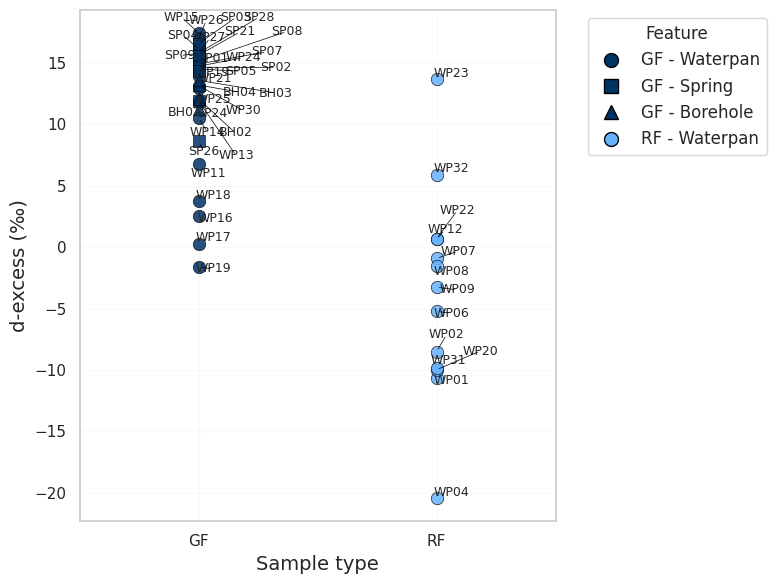

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from adjustText import adjust_text

# Clean column names (strip spaces)
df.columns = df.columns.str.strip()

# Define a function to classify features based on Code_1
def classify_feature(code):
    if str(code).startswith("WP"):
        return "Waterpan"
    elif str(code).startswith("SP"):
        return "Spring"
    elif str(code).startswith("BH"):
        return "Borehole"
    else:
        return "Other"

# Apply feature classification and remove 'Other'
df["Feature"] = df["Code_1"].apply(classify_feature)
df = df[df["Feature"] != "Other"]

# Convert D-excess to numeric and remove missing values
df["D-excess"] = pd.to_numeric(df["D-excess"], errors="coerce")
df = df.dropna(subset=["D-excess"])

# Define sample type colors
colors = {"GF": "#003366", "RF": "#66B2FF"}
marker_styles = {"Waterpan": "o", "Spring": "s", "Borehole": "^"}

# Define tighter x-axis positions to bring groups closer together
x_positions_map = {"GF": 0.45, "RF": 0.55}

# Start figure and axis
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Set tighter x-axis limits to center the groups visually
ax.set_xlim(0.4, 0.6)

# Store text annotations for adjust_text
texts = []

# Plot each group separately
for sample in colors:
    for feat in marker_styles:
        subset = df[(df["Type_3"] == sample) & (df["Feature"] == feat)]
        if not subset.empty:
            x_position = x_positions_map[sample]
            x_positions = np.full(len(subset), x_position)

            # Scatter plot
            ax.scatter(x=x_positions,
                       y=subset["D-excess"],
                       c=colors[sample],
                       marker=marker_styles[feat],
                       s=80,
                       alpha=0.85,
                       edgecolors='black',
                       linewidths=0.5)

            # Identify and print outliers
            Q1 = subset['D-excess'].quantile(0.25)
            Q3 = subset['D-excess'].quantile(0.75)
            IQR = Q3 - Q1
            outliers = subset[(subset['D-excess'] < Q1 - 1.5 * IQR) | (subset['D-excess'] > Q3 + 1.5 * IQR)]
            if not outliers.empty:
                print(f"Outliers for {sample} - {feat}:")
                for index, row in outliers.iterrows():
                    print(f"  Code_1: {row['Code_1']}, D-excess: {row['D-excess']}")

                    # Add labels for all points
            for i, row in subset.iterrows():
                text = ax.text(x_positions[subset.index.get_loc(row.name)], row["D-excess"], row["Code_1"], fontsize=9)
                texts.append(text)

# Adjust text labels
adjust_text(texts, force_points=(7, 7),
            autoalign='xy',
            only_move={'points': 'xy', 'text': 'xy'},
            expand_points=(20, 20),
            expand_text=(20, 20),
            arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

# X-axis setup
ax.set_xticks(list(x_positions_map.values()))
ax.set_xticklabels(list(x_positions_map.keys()))
ax.set_xlabel("Sample type", fontsize=14)
ax.set_ylabel("d-excess (‰)", fontsize=14)
ax.grid(alpha=0.1)

# Legend
legend_handles = []
for sample in colors:
    for feat in marker_styles:
        if not df[(df["Type_3"] == sample) & (df["Feature"] == feat)].empty:
            legend_handles.append(
                Line2D([0], [0],
                       marker=marker_styles[feat],
                       color='w',
                       markerfacecolor=colors[sample],
                       markeredgecolor='black',
                       markersize=10,
                       label=f"{sample} - {feat}")
            )

plt.legend(handles=legend_handles,
           title="Feature",
           loc='upper left',
           bbox_to_anchor=(1.05, 1),
           fontsize=12,
           title_fontsize=12)

plt.tight_layout()
plt.show()



In [ ]:
pip install adjustText

In [ ]:
# Equations:
# GMWL: δ²H = 8 * δ18O + 10
# LMWL: δ²H = 7.8 * δ18O + 12.5

# Solve for δ18O:
# 8 * δ18O + 10 = 7.6 * δ18O + 12.5  =>  0.4 * δ18O = 2.5
delta18O_intersect = 2.5 / 0.4
delta2H_intersect = 8 * delta18O_intersect + 10  # Using GMWL

print("Intersection of GMWL and LMWL:")
print("δ18O =", delta18O_intersect)
print("δ2H =", delta2H_intersect)


Intersection of GMWL and LMWL:
δ18O = 6.25
δ2H = 60.0


In [ ]:
df["d-excess"] = df["δ2H, in ‰"] - 8 * df["δ18O, in ‰"]


<ipython-input-359-13a785e2b366>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Feature", y="d-excess", data=df, palette="Set2")


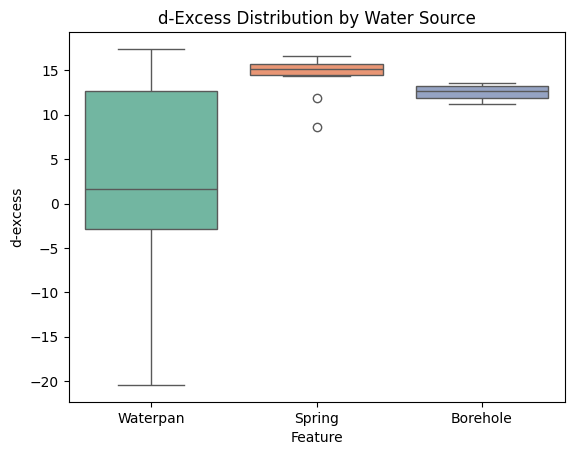

In [ ]:
df["d-excess"] = df["δ2H, in ‰"] - (8 * df["δ18O, in ‰"])
sns.boxplot(x="Feature", y="d-excess", data=df, palette="Set2")
plt.title("d-Excess Distribution by Water Source")
plt.show()

In [ ]:
# Calculate d-excess
df["d-excess"] = df["δ2H, in ‰"] - (8 * df["δ18O, in ‰"])

# Print the dataframe with d-excess values
print(df[["Code_1", "Feature", "δ2H, in ‰", "δ18O, in ‰", "d-excess"]])


   Code_1   Feature  δ2H, in ‰  δ18O, in ‰  d-excess
0    WP07  Waterpan       19.8        2.59     -0.92
1    WP08  Waterpan        8.2        1.22     -1.56
2    WP11  Waterpan       -7.9       -1.83      6.74
3    WP12  Waterpan       14.4        1.72      0.64
4    WP09  Waterpan       14.9        2.27     -3.26
5    SP02    Spring      -30.4       -5.63     14.64
6    WP14  Waterpan      -21.1       -3.95     10.50
7    WP15  Waterpan        9.4       -1.00     17.40
8    WP01  Waterpan       20.0        3.83    -10.64
9    WP02  Waterpan       26.2        4.34     -8.52
10   WP04  Waterpan       29.1        6.19    -20.42
11   WP06  Waterpan       21.8        3.38     -5.24
12   WP13  Waterpan       -8.6       -2.56     11.88
13   SP01    Spring      -30.1       -5.65     15.10
14   WP17  Waterpan       12.2        1.49      0.28
15   SP04    Spring      -22.6       -4.84     16.12
16   WP18  Waterpan        5.1        0.17      3.74
17   SP05    Spring      -22.4       -4.61    

In [ ]:
# Ensure the column names match your dataset
df["d_excess"] = df["δ2H, in ‰"] - 8 * df["δ18O, in ‰"]

# Display first few rows with d-excess
df[["Code_1", "Feature", "δ2H, in ‰", "δ18O, in ‰", "d_excess"]].head()


,Code_1,Feature,"δ2H, in ‰","δ18O, in ‰",d_excess
0,WP07,Waterpan,19.8,2.59,-0.92
1,WP08,Waterpan,8.2,1.22,-1.56
2,WP11,Waterpan,-7.9,-1.83,6.74
3,WP12,Waterpan,14.4,1.72,0.64
4,WP09,Waterpan,14.9,2.27,-3.26


In [ ]:
# Filter the dataset to include only Water Pans
df_wp = df[df["Feature"] == "Water Pan"].copy()

# Calculate d-excess for Water Pans
df_wp["d_excess"] = df_wp["δ2H, in ‰"] - 8 * df_wp["δ18O, in ‰"]

# Display first few rows of Water Pan dataset with d-excess
df_wp[["Code_1", "δ2H, in ‰", "δ18O, in ‰", "d_excess"]].head()


,Code_1,"δ2H, in ‰","δ18O, in ‰",d_excess


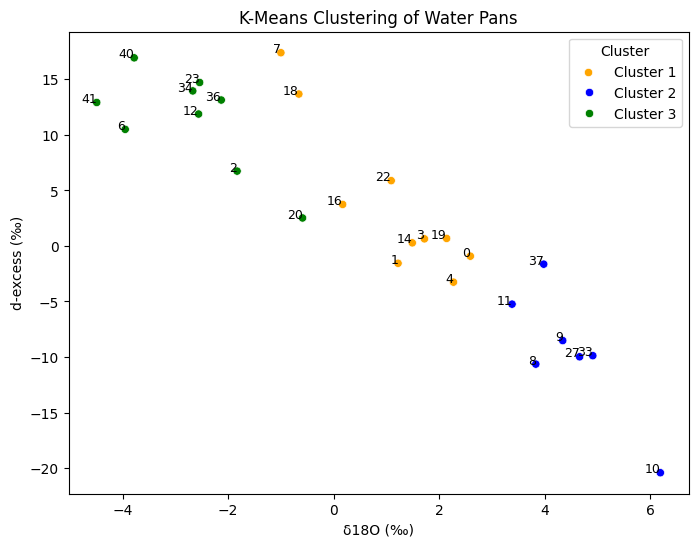

In [ ]:
from sklearn.cluster import KMeans

# Select the features for clustering
X = df_wp[["δ18O, in ‰", "δ2H, in ‰", "d_excess"]]

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)  # Adjust clusters as needed
df_wp["Cluster"] = kmeans.fit_predict(X)

# Define colors for clusters
colors = {0: "blue", 1: "green", 2: "orange"}

# Scatter plot with clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_wp["δ18O, in ‰"], y=df_wp["d_excess"], hue=df_wp["Cluster"], palette=colors)

# Label each water pan
for i, row in df_wp.iterrows():
    plt.text(row["δ18O, in ‰"], row["d_excess"], row.name, fontsize=9, ha='right')

# Plot formatting
plt.xlabel("δ18O (‰)")
plt.ylabel("d-excess (‰)")
plt.title("K-Means Clustering of Water Pans")

plt.legend(title="Cluster", labels=["Cluster 1", "Cluster 2", "Cluster 3"])
plt.show()


In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_wp["δ18O, in ‰"], y=df_wp["d_excess"], hue=df_wp["Cluster"], palette=colors)
plt.xlabel("δ18O (‰)")
plt.ylabel("d-excess (‰)")
plt.title("Clustering of Water Pans (δ18O vs d-excess)")
plt.show()


Higher d-excess → More groundwater influence.
Lower d-excess → More evaporation **influence** **bold text** **bold text**

In [ ]:
!pip install adjustText


In [ ]:
from adjustText import adjust_text


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# Scatter plot
sns.scatterplot(x=df_wp["δ18O, in ‰"], y=df_wp["d_excess"], color="blue")

# Label each water pan with an offset to prevent overlap
for i, row in df_wp.iterrows():
    plt.text(row["δ18O, in ‰"], row["d_excess"] + 0.5, row["Code_1"], fontsize=9, ha='right', va='bottom')

# Labels and Title
plt.xlabel("δ18O (‰)")
plt.ylabel("d-excess (‰)")
plt.title("d-excess vs δ18O for Water Pans")

# Show plot
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler

# Select clustering features
X = df_wp[["δ18O, in ‰", "d_excess"]]

# Scale the data (optional, but helps with clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_wp["Cluster"] = kmeans.fit_predict(X_scaled)


In [ ]:
# Define colors for clusters
colors = {0: "blue", 1: "green"}

plt.figure(figsize=(8,6))

# Scatter plot of d-excess vs δ18O with clusters
sns.scatterplot(data=df_wp, x="δ18O, in ‰", y="d_excess", hue=df_wp["Cluster"], palette=colors)

# Add labels for water pans
for i, row in df_wp.iterrows():
    plt.text(row["δ18O, in ‰"], row["d_excess"] + 0.5, row["Code_1"], fontsize=9, ha='right')

# Labels and title
plt.xlabel("δ18O (‰)")
plt.ylabel("d-excess (‰)")
plt.title("Water Pan Clusters (k=2)")

plt.legend(title="Cluster", labels=["Cluster 1", "Cluster 2"])
plt.show()


In [ ]:
df_wp.groupby("Cluster")["d_excess"].mean()


In [ ]:
# Group the data by Feature (Water Pan, Spring, Borehole) and print the d-excess values for each
grouped_d_excess = df.groupby("Feature")["d_excess"].apply(list)

# Print the d-excess values for each water source
print(grouped_d_excess)


In [ ]:
# Print the column names to check the exact name of the column
print(df.columns)


In [ ]:
# Group the data by Feature (Water Pan, Spring, Borehole) and print the d-excess values for each
grouped_d_excess = df.groupby("Feature")["d_excess"].apply(list)

# Print the d-excess values for each water source
print(grouped_d_excess)


In [ ]:
# Group the data by Feature (Water Pan, Spring, Borehole) and print the d-excess values for each
grouped_d_excess = df.groupby("Feature")["d_excess"].apply(list)

# Save the grouped data to a CSV file
grouped_d_excess.to_csv('/content/grouped_d_excess.csv', header=True)

# Notify the user that the file has been saved
print("CSV file saved as 'grouped_d_excess.csv'")


In [ ]:
# Recalculate d-excess based on δ²H and δ¹⁸O
df['d_excess_calculated'] = df['δ2H, in ‰'] - 8 * df['δ18O, in ‰']

# Check for any discrepancies
df[['Code_1', 'd_excess', 'd_excess_calculated']].head()


In [ ]:
# Replace the d_excess values with the recalculated ones
df['d_excess'] = df['d_excess_calculated']

# Verify the updated values
print(df[['Code_1', 'd_excess']].head())


In [ ]:
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Assuming df has the isotopic data
X = df[['δ2H, in ‰', 'δ18O, in ‰', 'd_excess']].dropna()

# Perform hierarchical clustering
clustering = AgglomerativeClustering(n_clusters=2)  # Specify 3 clusters
df['Cluster'] = clustering.fit_predict(X)  # Add cluster labels to the dataframe

# Create a dendrogram to visualize the clusters with horizontal distance
linked = linkage(X, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked, labels=df['Code_1'].to_numpy(), orientation='right')  # Change orientation to horizontal
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Distance')
plt.ylabel('Water Pan')
plt.show()

# Display the clusters with labels
print(df[['Code_1', 'Cluster']])

# Visualize the clusters using a scatter plot
sns.scatterplot(x="δ2H, in ‰", y="δ18O, in ‰", hue="Cluster", data=df, palette="Set2", s=100)
plt.title("Clustered Water Pans Based on Isotopic Data")
plt.xlabel("δ²H (‰)")
plt.ylabel("δ¹⁸O (‰)")
plt.show()




In [ ]:
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Assuming df has the isotopic data
X = df[['δ2H, in ‰', 'δ18O, in ‰', 'd_excess']].dropna()

# Perform hierarchical clustering with 2 clusters
clustering = AgglomerativeClustering(n_clusters=2)  # Specify 2 clusters
df['Cluster'] = clustering.fit_predict(X)  # Add cluster labels to the dataframe

# Create a dendrogram to visualize the clusters
linked = linkage(X, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked, labels=df['Code_1'].to_numpy())
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Water Pan')
plt.ylabel('Distance')
plt.show()

# Display the clusters with labels
print(df[['Code_1', 'Cluster']])

# Visualize the clusters using a scatter plot with δ²H on the vertical axis
sns.scatterplot(x="δ18O, in ‰", y="δ2H, in ‰", hue="Cluster", data=df, palette="Set2", s=100)
plt.title("Clustered Water Pans Based on Isotopic Data")
plt.xlabel("δ¹⁸O (‰)")
plt.ylabel("δ²H (‰)")

# Define the Global Meteoric Water Line (GMWL)
x_gmwl = np.linspace(min(df["δ18O, in ‰"]) - 2, max(df["δ18O, in ‰"]) + 2, 100)
y_gmwl = 8 * x_gmwl + 10  # GMWL equation

# Plot the Global Meteoric Water Line (GMWL)
plt.plot(x_gmwl, y_gmwl, color='red', linestyle='--', label="GMWL: δ2H = 8 * δ18O + 10")

plt.show()



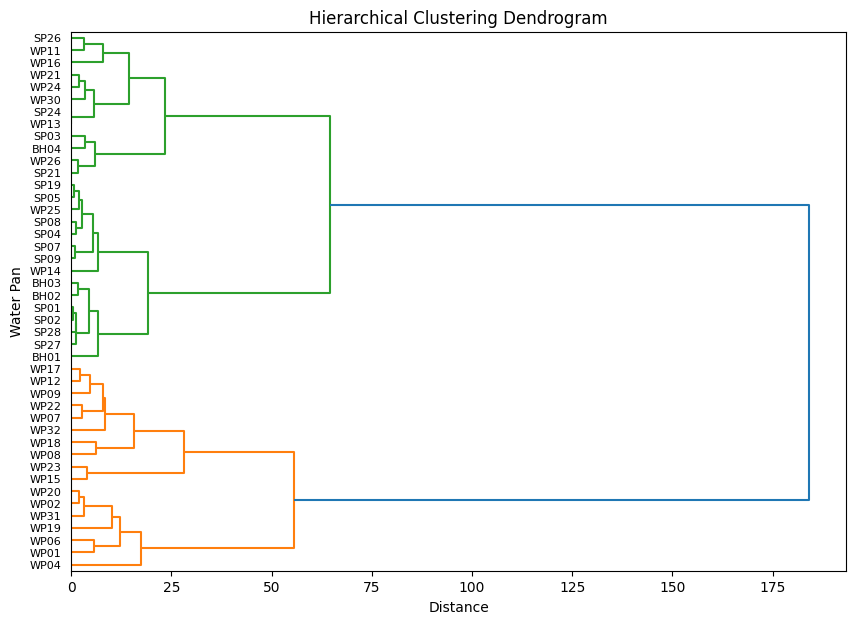

   Code_1  Cluster
0    WP07        1
1    WP08        1
2    WP11        0
3    WP12        1
4    WP09        1
5    SP02        0
6    WP14        0
7    WP15        1
8    WP01        1
9    WP02        1
10   WP04        1
11   WP06        1
12   WP13        0
13   SP01        0
14   WP17        1
15   SP04        0
16   WP18        1
17   SP05        0
18   WP23        1
19   WP22        1
20   WP16        0
21   BH01        0
22   WP32        1
23   WP24        0
24   SP24        0
25   SP27        0
26   SP28        0
27   WP20        1
29   SP09        0
30   SP08        0
31   SP07        0
32   BH04        0
33   WP31        1
34   WP21        0
35   SP21        0
36   WP30        0
37   WP19        1
38   SP19        0
39   BH02        0
40   WP26        0
41   WP25        0
42   SP03        0
43   BH03        0
44   SP26        0


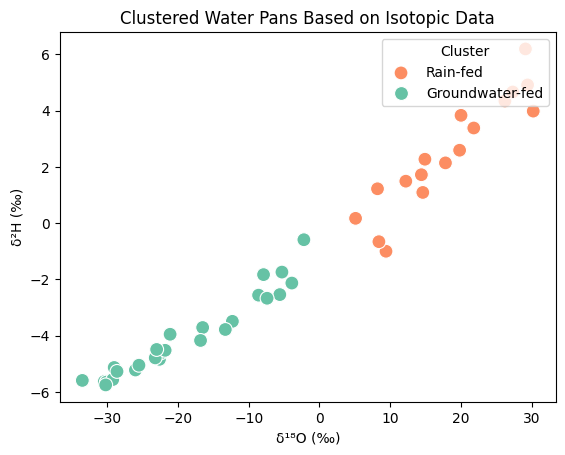

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Assuming df has the isotopic data
X = df[['δ2H, in ‰', 'δ18O, in ‰', 'd_excess']].dropna()

# Perform hierarchical clustering
clustering = AgglomerativeClustering(n_clusters=2)  # Specify 2 clusters
df['Cluster'] = clustering.fit_predict(X)  # Add cluster labels to the dataframe

# Create a dendrogram to visualize the clusters with horizontal distance
linked = linkage(X, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked, labels=df['Code_1'].to_numpy(), orientation='right')  # Change orientation to horizontal
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Distance')
plt.ylabel('Water Pan')
plt.show()

# Display the clusters with labels
print(df[['Code_1', 'Cluster']])

# Map cluster numbers to custom labels
cluster_labels = {0: 'Rain-fed', 1: 'Groundwater-fed'}

# Visualize the clusters using a scatter plot
sns.scatterplot(x="δ2H, in ‰", y="δ18O, in ‰", hue="Cluster", data=df, palette="Set2", s=100)

# Customize the legend with Rain-fed and Groundwater-fed labels
plt.title("Clustered Water Pans Based on Isotopic Data")
plt.xlabel("δ¹⁸O (‰)")
plt.ylabel("δ²H (‰)")
plt.legend(title='Cluster', labels=[cluster_labels[i] for i in range(2)], loc='upper right')
plt.show()


In [ ]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df has the isotopic data with 'd_excess' and 'δ18O, in ‰'
X = df[['δ18O, in ‰', 'd_excess']].dropna()  # Selecting relevant columns for clustering

# Apply K-means clustering (2 clusters for Rainfed and Groundwater-fed)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df has the isotopic data with 'd_excess' and 'δ18O, in ‰'
X = df[['δ18O, in ‰', 'd_excess']].dropna()  # Selecting relevant columns for clustering

# Apply K-means clustering (2 clusters for Rainfed and Groundwater-fed)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Map cluster labels to water source categories (Rain-fed and Groundwater-fed)
cluster_mapping = {1: 'Rain-fed', 2: 'Groundwater/fed', 3: 'Mixed sources'}  # Customize mapping based on your clusters
df['Water Source'] = df['Cluster'].map(cluster_mapping)

# Get the cluster centers
centers = kmeans.cluster_centers_

# Set the style for the plot
sns.set(style="whitegrid")

# Plot the scatter plot with different colors and markers for each cluster
plt.figure(figsize=(10, 7))

# Use scatterplot with different markers for each water source
sns.scatterplot(x="δ18O, in ‰", y="d_excess", hue="Water Source", style="Water Source", data=df,
                palette="Set2", s=100, markers={"Rain-fed": "o", "Groundwater/fed": "s", "Mixed sources": "X"})

# Plot the cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=50, label='Cluster Center')

# Title and labels
plt.title("K-means Cluster of d-excess vs δ¹⁸O (Oxygen-18) with Water Sources and Cluster Centers")
plt.xlabel("δ¹⁸O (‰) - Oxygen-18")
plt.ylabel("D-excess (‰)")

# Show the legend with the labels for water sources and cluster centers
plt.legend(title="Water Source", loc='upper left', bbox_to_anchor=(1, 1))

# Display the plot
plt.show()
# Get the cluster centers
centers = kmeans.cluster_centers_

# Set the style for the plot
sns.set(style="whitegrid")

# Plot the scatter plot with different colors and markers for each cluster
plt.figure(figsize=(10, 7))

# Use scatterplot with different markers for each water source
sns.scatterplot(x="δ18O, in ‰", y="d_excess", hue="Water Source", style="Water Source", data=df,
                palette="Set2", s=100, markers={"Rain-fed": "o", "Groundwater/fed": "s"})

# Plot the cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=50, label='Cluster Center')

# Title and labels
plt.title("K-means Cluster of d-excess vs δ¹⁸O (Oxygen-18) with Water Sources and Cluster Centers")
plt.xlabel("δ¹⁸O (‰) - Oxygen-18")
plt.ylabel("D-excess (‰)")

# Show the legend with the labels for water sources and cluster centers
plt.legend(title="Water Source", loc='upper left', bbox_to_anchor=(1, 1))

# Display the plot
plt.show()


In [ ]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df has your data
X = df[['δ2H, in ‰', 'δ18O, in ‰', 'd_excess']]  # You can adjust the features

# Perform K-means clustering for 2 clusters (e.g., rainfed and groundwater-fed)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Get the cluster centers (centroids)
centroids = kmeans.cluster_centers_

# Plot the data with clusters
plt.figure(figsize=(10, 7))

# Scatter plot for isotopic values with clustering
sns.scatterplot(x="δ2H, in ‰", y="δ18O, in ‰", hue="Cluster", data=df, palette="Set2", s=100)

# Plot the cluster centers (centroids) as black X markers
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label="Cluster Centers")

# Add title and labels
plt.title("Q-mode Clustering of Water Sources Based on Isotopic Data")
plt.xlabel("δ²H (‰)")
plt.ylabel("δ¹⁸O (‰)")
plt.legend(title="Cluster", loc='upper left')

# Show plot
plt.show()


In [ ]:
df.head()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the dataset (assuming df is already loaded)
df_waterpans = df[df['Feature'] == 'Water Pan'].copy()  # Ensure only water pans are included

# Ensure no missing values
df_waterpans = df_waterpans.dropna(subset=['δ2H, in ‰', 'δ18O, in ‰'])

# Extract relevant features for clustering
X = df_waterpans[['δ2H, in ‰', 'δ18O, in ‰']]

# Determine the best number of clusters using the elbow method
inertia = []
silhouette_scores = []
K_range = range(2, 6)  # Testing for 2 to 5 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Plot elbow method
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

# Plot silhouette scores
plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='-')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Analysis')
plt.show()

# Run K-Means with the best number of clusters (based on elbow/silhouette results)
optimal_k = 3  # Adjust based on your results
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_waterpans['Cluster'] = kmeans.fit_predict(X) + 1  # Adjust to start from 1 instead of 0

# Assign cluster labels (1 = Rain-fed, 2 = Groundwater-fed, 3 = Mixed sources)
df_waterpans['Water Source'] = df_waterpans['Cluster'].map({1: 'Rain-fed', 2: 'Groundwater-fed', 3: 'Mixed sources'})

# Scatter plot of δ18O vs. d-excess with cluster labels
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_waterpans, x='δ18O, in ‰', y='d_excess', hue='Water Source', style='Water Source', s=100)
plt.xlabel("δ¹⁸O (‰)")
plt.ylabel("Deuterium excess (‰)")
plt.title("Cluster Analysis of Water Pans")
plt.legend(title='Water Source')
plt.grid(True)
plt.show()



In [ ]:
# Save the clustered results to a CSV file
df_waterpans.to_csv("clustered_waterpans.csv", index=False)

print("Clustered results saved as 'clustered_waterpans.csv'")


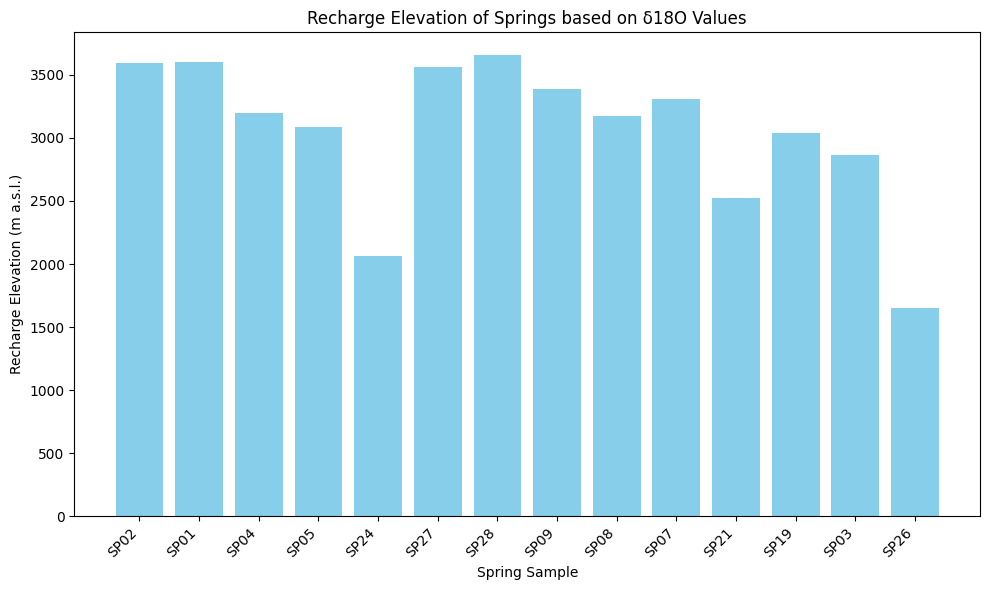

,Spring,δ18O_spring,Elevation_difference,Recharge_elevation
0,SP02,-5.63,1465.0,3595.0
1,SP01,-5.65,1475.0,3605.0
2,SP04,-4.84,1070.0,3200.0
3,SP05,-4.61,955.0,3085.0
4,SP24,-2.56,-70.0,2060.0
5,SP27,-5.56,1430.0,3560.0
6,SP28,-5.75,1525.0,3655.0
7,SP09,-5.22,1260.0,3390.0
8,SP08,-4.79,1045.0,3175.0
9,SP07,-5.05,1175.0,3305.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Spring sample data with δ18O values
spring_data = {
    'Spring': ['SP02', 'SP01', 'SP04', 'SP05', 'SP24', 'SP27', 'SP28', 'SP09', 'SP08', 'SP07', 'SP21', 'SP19', 'SP03', 'SP26'],
    'δ18O_spring': [-5.63, -5.65, -4.84, -4.61, -2.56, -5.56, -5.75, -5.22, -4.79, -5.05, -3.49, -4.52, -4.17, -1.74],
    'Altitude_spring': [None]*14,  # Placeholder, as we're calculating recharge elevation
}

# Precipitation data
δ18O_precip = -2.7
precip_altitude = 2130
gradient = -0.2  # ‰ per 100 m

# Create DataFrame for spring data
spring_df = pd.DataFrame(spring_data)

# Calculate elevation differences and recharge elevations
spring_df['Elevation_difference'] = (spring_df['δ18O_spring'] - δ18O_precip) / gradient * 100  # Elevation difference in meters
spring_df['Recharge_elevation'] = precip_altitude + spring_df['Elevation_difference']

# Plot the recharge elevations
plt.figure(figsize=(10, 6))
plt.bar(spring_df['Spring'], spring_df['Recharge_elevation'], color='skyblue')
plt.xlabel('Spring Sample')
plt.ylabel('Recharge Elevation (m a.s.l.)')
plt.title('Recharge Elevation of Springs based on δ18O Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display the results in tabular form
spring_df[['Spring', 'δ18O_spring', 'Elevation_difference', 'Recharge_elevation']]


In [ ]:
# Find the d-excess value for the SW01 sample
sw01_dexcess = df[df['Code_1'] == 'SW01']['D-excess'].iloc[0]
print(f"The d-excess value for SW01 is: {sw01_dexcess:.2f} ‰")

IndexError: single positional indexer is out-of-bounds

In [ ]:
# Check if SW01 exists in the DataFrame
if 'SW01' in df['Code_1'].values:
    # Find the d-excess value for the SW01 sample
    sw01_row = df[df['Code_1'] == 'SW01']
    if not sw01_row.empty:
        sw01_dexcess = sw01_row['D-excess'].iloc[0]
        print(f"The d-excess value for SW01 is: {sw01_dexcess:.2f} ‰")
    else:
        print("SW01 sample found in 'Code_1' column but row is empty after filtering.")
else:
    print("SW01 sample not found in the 'Code_1' column of the DataFrame.")

# Display the first few rows and columns to inspect the data
display(df[['Code_1', 'Feature', 'D-excess']].head())

SW01 sample not found in the 'Code_1' column of the DataFrame.


,Code_1,Feature,D-excess
0,WP07,Water Pan,-0.92
1,WP08,Water Pan,-1.56
2,WP11,Water Pan,6.74
3,WP12,Water Pan,0.64
4,WP09,Water Pan,-3.26
